In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from nn.nn import NeuralNetwork

In [2]:
digits = load_digits()

X = digits.data   # shape: (n_samples, 64)
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature min/max before scaling:", X.min(), X.max())

X shape: (1797, 64)
y shape: (1797,)
Feature min/max before scaling: 0.0 16.0


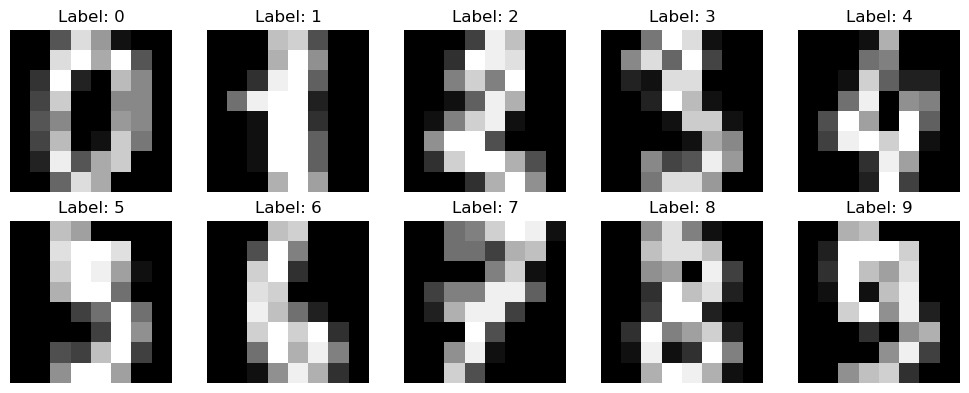

In [3]:
# Examine a few example digits

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
X_train, X_val = train_test_split(
    X,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (1437, 64)
Validation shape: (360, 64)


In [5]:
# Scale values to a normalized range.

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Scaled training min/max:", X_train.min(), X_train.max())
print("Scaled validation min/max:", X_val.min(), X_val.max())

Scaled training min/max: 0.0 1.0
Scaled validation min/max: 0.0 1.3


In [16]:
nn_arch = [
    {"input_dim": 64, "output_dim": 16, "activation": "relu"},
    {"input_dim": 16, "output_dim": 64, "activation": "sigmoid"},
]

autoencoder = NeuralNetwork(
    nn_arch=nn_arch,
    lr=0.01,
    seed=42,
    batch_size=32,
    epochs=200,
    loss_function="mean_squared_error"
)

print(autoencoder.arch)

[{'input_dim': 64, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'}]


In [17]:
train_losses, val_losses = autoencoder.fit(
    X_train, X_train,
    X_val, X_val
)

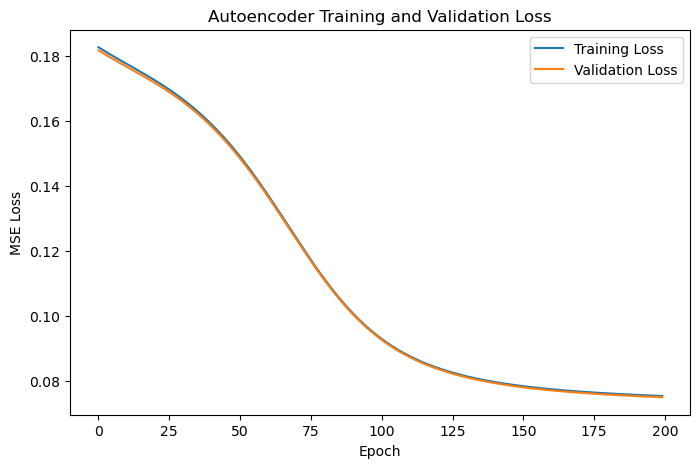

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

In [19]:
X_val_reconstructed, _ = autoencoder.forward(X_val)

val_reconstruction_error = mean_squared_error(X_val, X_val_reconstructed)

print("Average validation reconstruction error (MSE):", val_reconstruction_error)

Average validation reconstruction error (MSE): 0.07507187725313885


In [ ]:
# Justifications: 
# I chose a dimensional shift of 64 => 16 => 64 because that assignment explicilty 
# asked for this dimensionality. I chose a learning rate of 0.01 as a compromise between
# instability and overfitting. I trained for 200 epochs to give the model enough time to 
# level off after achieving diminishing returns around the 100~ epoch range. I chose MSE 
# because this isn't a classification task-- we want to understand the loss of the model in
# terms of the difference between the predicted input and the actual input.